In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Configuracion global de visualizacion
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid', palette='viridis')

# Configuracion de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 3.0.5
numpy: 2.5.2


In [29]:
df_casas=pd.read_csv('house-prices-tp.csv')

In [30]:
df_casas

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,0.0824,30.0000,4.9300,0.0000,0.4280,6.4810,18.5000,6.1899,6.0000,300.0000,16.6000,379.4100,6.3600,23.7000
552,0.4755,0.0000,9.9000,0.0000,0.5440,6.1130,58.8000,4.0019,4.0000,304.0000,18.4000,396.2300,12.7300,21.0000
553,0.2498,0.0000,21.8900,0.0000,0.6240,5.8570,98.2000,1.6686,4.0000,437.0000,21.2000,392.0400,21.3200,13.3000
554,32.5040,6.5286,8.9373,1.0000,NaN,4.0166,NaN,5.2438,20.4169,197.2366,19.6391,6.2671,7.0340,23.0288


In [31]:
df_casas.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [32]:
df_casas.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,533.0000,534.0000,541.0000,533.0000,532.0000,535.0000,532.0000,541.0000,528.0000,538.0000,528.0000,534.0000,534.0000,535.0000
mean,5.8455,13.1972,11.2187,0.0901,0.5600,6.2918,67.6323,3.9441,9.6994,409.5751,18.4299,347.8060,13.0281,22.7468
std,13.8286,24.9030,6.9420,0.2865,0.1195,0.7824,28.4619,2.2557,8.6845,167.6894,2.1948,99.6362,7.5800,9.4915
min,0.0063,0.0000,0.4600,0.0000,0.3850,3.5610,2.9000,1.1296,1.0000,187.0000,12.6000,0.3200,1.7300,5.0000
25%,0.0845,0.0000,5.1300,0.0000,0.4530,5.8755,42.2750,2.1121,4.0000,279.0000,17.0000,369.5300,7.1500,16.7500
50%,0.3153,0.0000,9.6900,0.0000,0.5380,6.2080,76.5000,3.3401,5.0000,335.0000,19.0000,390.8150,11.4650,21.2000
75%,4.8714,20.0000,18.1000,0.0000,0.6440,6.6385,93.8250,5.4007,23.6327,666.0000,20.2000,395.8900,17.2050,26.3000
max,88.9762,100.0000,27.7400,1.0000,0.8710,8.7800,100.0000,12.1265,24.0000,711.0000,22.0000,396.9000,37.9700,50.0000


## Carga e Inspección Estructural del Dataset

### Sobre el dataset House Prices (Boston Housing)

El dataset contiene información de 556 registros de propiedades con las siguientes 14 variables:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `CRIM` | Continua | Tasa de criminalidad per cápita por municipio |
| `ZN` | Continua | Proporción de suelo residencial zonificado para lotes de más de 25.000 pies cuadrados |
| `INDUS` | Continua | Proporción de acres comerciales no minoristas por municipio |
| `CHAS` | Categórica | Variable ficticia del río Charles (1 si limita con el río; 0 en caso contrario) |
| `NOX` | Continua | Concentración de óxidos nítricos (indicador de contaminación del aire) |
| `RM` | Continua | Cantidad promedio de habitaciones por vivienda |
| `AGE` | Continua | Proporción de viviendas antiguas (construidas antes de 1940) ocupadas por sus dueños |
| `DIS` | Continua | Distancias ponderadas a cinco grandes centros de empleo |
| `RAD` | Discreta | Índice de accesibilidad a las autopistas radiales |
| `TAX` | Continua | Tasa de impuesto a la propiedad por cada $10.000 |
| `PTRATIO` | Continua | Proporción de alumnos por maestro en la zona |
| `B` | Continua | Índice matemático relacionado a la proporción de población afroamericana |
| `LSTAT` | Continua | Porcentaje de la población considerada de bajo estatus socioeconómico |
| `MEDV` | Continua | **Variable objetivo:** Valor mediano de las viviendas en miles de dólares ($1000s) |

### Vamos a observar la cantidad/porcentaje de nulos por columnas

In [33]:
nulos = df_casas.isnull().sum()
pct_nulos = (nulos / len(df_casas)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_casas.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_casas.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        23          4.1367  float64
ZN          22          3.9568  float64
INDUS       15          2.6978  float64
CHAS        23          4.1367  float64
NOX         24          4.3165  float64
RM          21          3.7770  float64
AGE         24          4.3165  float64
DIS         15          2.6978  float64
RAD         28          5.0360  float64
TAX         18          3.2374  float64
PTRATIO     28          5.0360  float64
B           22          3.9568  float64
LSTAT       22          3.9568  float64
MEDV        21          3.7770  float64

Total de celdas con nulos: 306 (3.9311% del dataset)


    Notamos que nuestra variable target "MEDV" posee nulos (cant = 21). Como no podemos rellenar datos sobre esta variable, ya que seria inventar datos sobre nuestra variable objetivo y por ende sesgar totalmente nuestro modelo, vamos a dropear todas las filas en las que esta tenga un valor nulo.

In [34]:
df_casas['RAD'].unique()

array([ 3.        ,  4.        ,  5.        ,  1.        ,  8.        ,
       24.        , 10.5548915 ,  7.        ,  2.        ,         nan,
        6.        , 14.63832996, 17.0001503 ,  6.85012281, 22.06951085,
        1.30712763, 17.16456963, 10.16870119, 21.90077626, 15.23957943,
        4.8117484 , 19.26689099,  3.05654826, 23.51021334, 17.11018134,
       18.17750289,  2.40242419,  4.52856858,  2.57361455, 22.32831295,
       14.19552773, 20.41690761])

In [35]:
df_casas_limpio = df_casas.dropna(subset=['MEDV'])

In [36]:
df_casas_limpio['RAD'].unique()

array([ 3.        ,  4.        ,  5.        ,  1.        ,  8.        ,
       24.        , 10.5548915 ,  7.        ,  2.        ,         nan,
        6.        , 14.63832996, 17.0001503 ,  6.85012281, 22.06951085,
        1.30712763, 17.16456963, 10.16870119, 21.90077626, 15.23957943,
        4.8117484 ,  3.05654826, 17.11018134,  2.40242419,  2.57361455,
       14.19552773, 20.41690761])

In [37]:
df_casas_limpio['RAD'] = df_casas_limpio['RAD'].round()
valores_validos_rad = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 24.0]

# 3. Calculamos la mediana
mediana_rad = df_casas_limpio['RAD'].median()

# 4. Filtramos: Si el valor NO está en la lista de válidos (o es NaN), lo pisamos con la mediana
df_casas_limpio.loc[~df_casas_limpio['RAD'].isin(valores_validos_rad), 'RAD'] = mediana_rad

In [38]:
nulos = df_casas_limpio.isnull().sum()
pct_nulos = (nulos / len(df_casas_limpio)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_casas_limpio.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_casas_limpio.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        11          2.0561  float64
ZN          11          2.0561  float64
INDUS        4          0.7477  float64
CHAS         9          1.6822  float64
NOX          9          1.6822  float64
RM           7          1.3084  float64
AGE         11          2.0561  float64
DIS          5          0.9346  float64
RAD          0          0.0000  float64
TAX          9          1.6822  float64
PTRATIO      9          1.6822  float64
B            9          1.6822  float64
LSTAT        9          1.6822  float64
MEDV         0          0.0000  float64

Total de celdas con nulos: 103 (1.3752% del dataset)


    Vemos que al dropear las lineas que tienen nulos en la variable target, el porcentaje de nulos se reduce mas de un 50%. A continuacion veremos como trabajar con los nulos restantes

### Separamos todas las filas que tienen algun nulo en un nuevo dataframe

In [39]:
df_nulos = df_casas_limpio[df_casas_limpio.isnull().any(axis=1)]
df_nulos

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
14,30.9865,60.7115,8.8272,0.0000,0.7476,NaN,23.5934,5.0625,5.0000,621.3307,16.6349,60.1620,30.4948,23.6754
23,73.6057,90.4347,12.7403,0.0000,NaN,8.0501,22.5424,5.7312,5.0000,NaN,21.2916,NaN,NaN,28.1301
66,NaN,57.3495,3.0478,1.0000,0.8139,4.3715,42.0051,NaN,5.0000,260.0063,16.8671,95.2918,NaN,30.0891
88,NaN,51.4067,NaN,NaN,NaN,NaN,8.0227,NaN,5.0000,NaN,18.3460,NaN,NaN,35.8650
128,NaN,NaN,13.6140,1.0000,0.6554,6.9344,26.1907,10.5900,7.0000,433.5793,12.7216,81.8895,NaN,12.9376
158,NaN,16.0260,NaN,0.0000,0.8158,7.6807,16.3767,10.7724,5.0000,NaN,NaN,99.9282,NaN,49.0005
172,48.3319,12.3063,25.4002,1.0000,0.7618,NaN,77.5480,10.3482,5.0000,NaN,15.5791,219.0445,29.7366,14.4423
203,2.0876,NaN,3.7731,NaN,NaN,NaN,72.4877,1.8957,5.0000,592.6382,15.3468,NaN,36.2203,45.2828
223,NaN,NaN,15.5236,NaN,NaN,NaN,35.5404,1.9678,1.0000,NaN,13.3648,200.6252,NaN,40.6947
230,23.7853,67.3783,21.0065,0.0000,0.8591,8.4211,70.7801,5.8163,5.0000,NaN,20.1837,370.9914,9.3324,24.2417


ver maximas cantidades de nulos que afectan 


### Tomamos la decision de borar todas las filas que tengan un 50% o mas de datos faltantes en dicha fila.

In [40]:
df_casas_limpio = df_casas_limpio.dropna(thresh=len(df_casas_limpio.columns)*0.5)
df_casas_limpio.info()

<class 'pandas.DataFrame'>
Index: 533 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     524 non-null    float64
 1   ZN       523 non-null    float64
 2   INDUS    531 non-null    float64
 3   CHAS     525 non-null    float64
 4   NOX      526 non-null    float64
 5   RM       527 non-null    float64
 6   AGE      523 non-null    float64
 7   DIS      529 non-null    float64
 8   RAD      533 non-null    float64
 9   TAX      525 non-null    float64
 10  PTRATIO  525 non-null    float64
 11  B        526 non-null    float64
 12  LSTAT    526 non-null    float64
 13  MEDV     533 non-null    float64
dtypes: float64(14)
memory usage: 62.5 KB


    Notamos que se eliminan 3 filas del dataset que tienen 50% o mas de sus datos faltantes.

FILTRO DE COLUMNAS NUMERICAS: RELLENAR

In [41]:
columnas_numericas = [col for col in df_casas_limpio.columns if col != 'CHAS' and col != 'RAD']


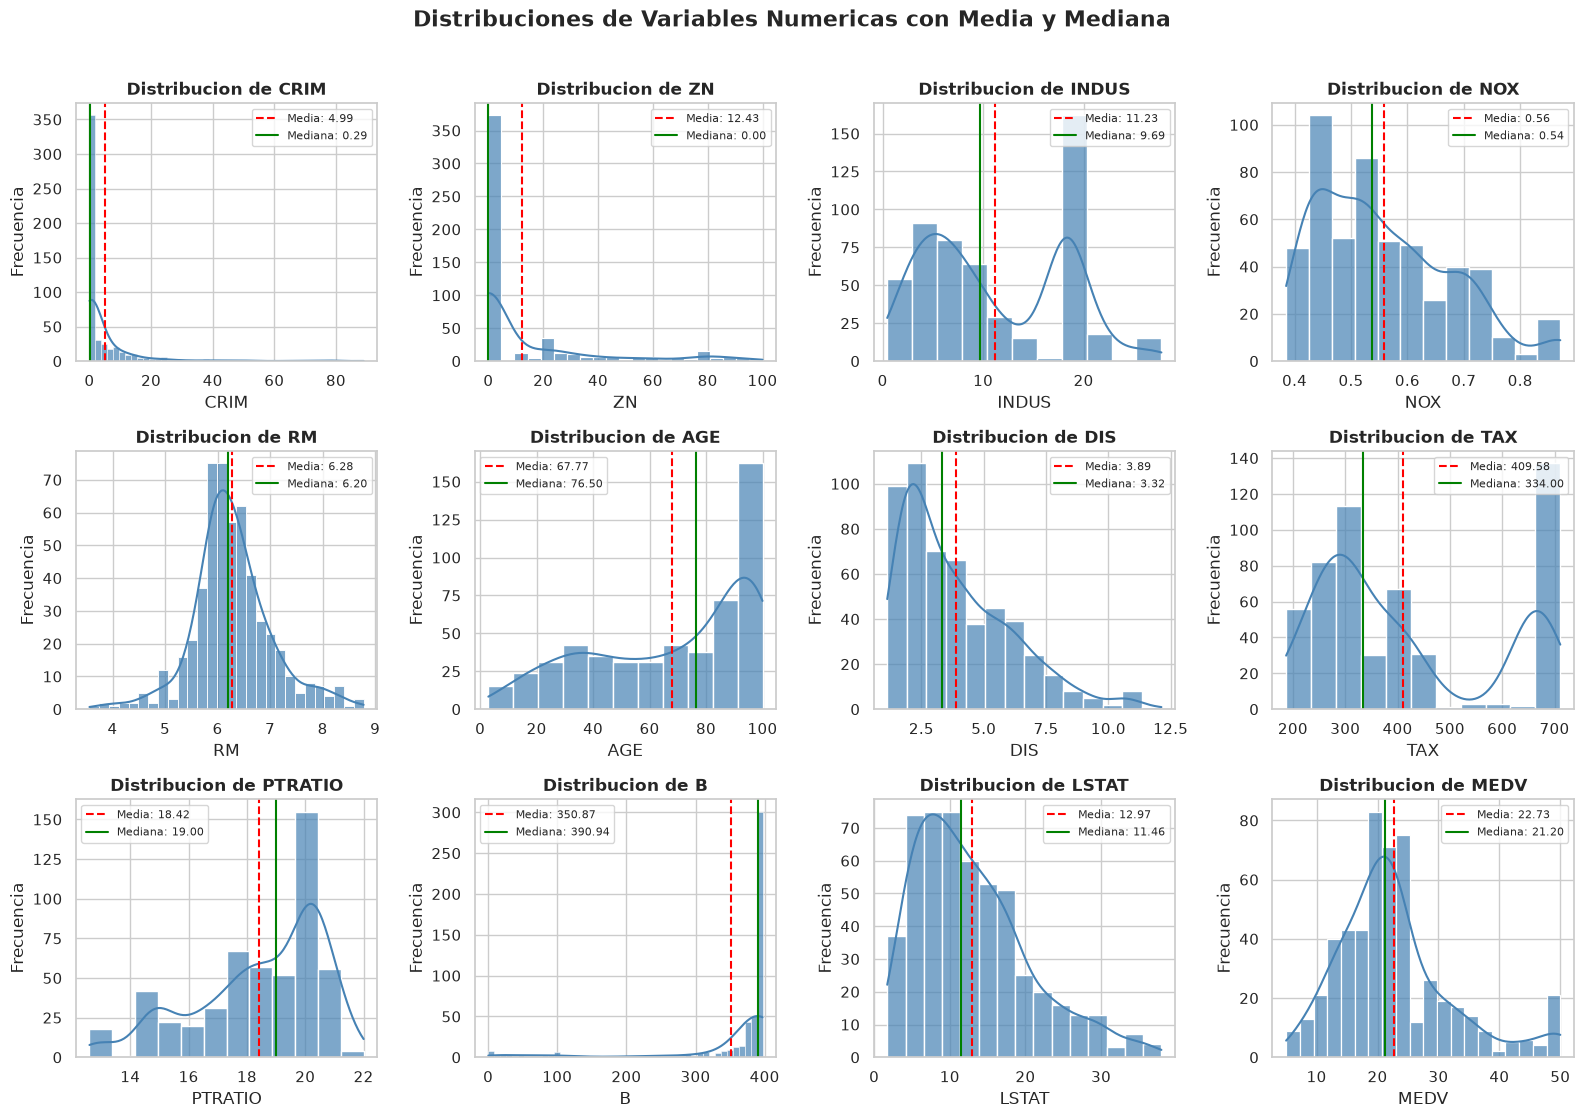

In [42]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    sns.histplot(df_casas_limpio[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = df_casas_limpio[col].mean()
    mediana = df_casas_limpio[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivamos los ejes basándonos en la nueva cantidad de columnas
for j in range(len(columnas_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numericas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

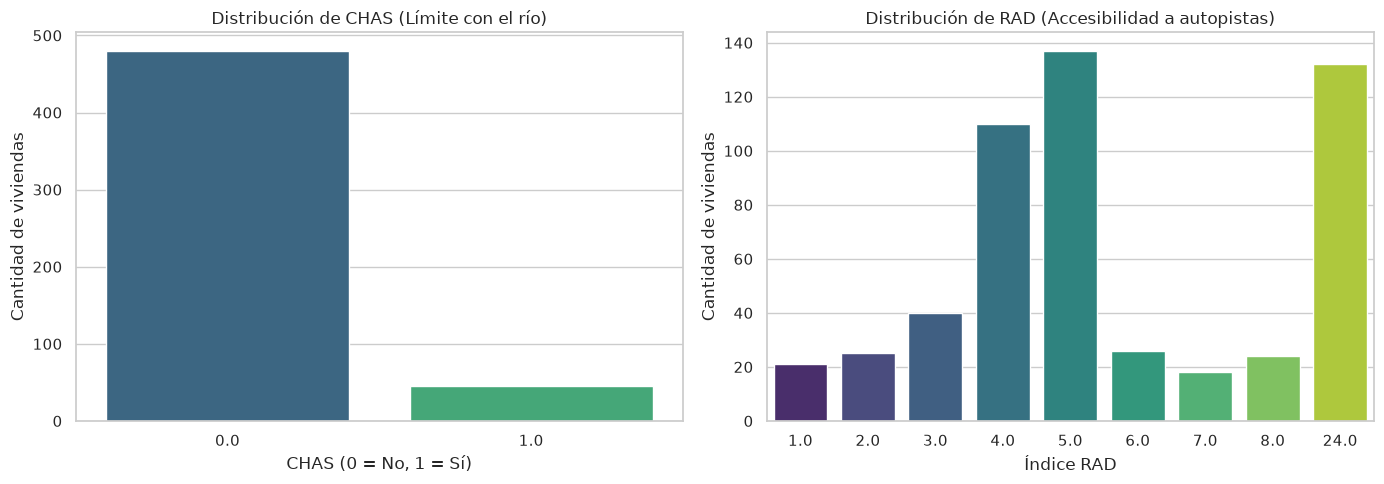

In [43]:
# Creamos una figura con dos subgráficos (uno al lado del otro)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para CHAS (Variable binaria/categórica)
sns.countplot(data=df_casas_limpio, x='CHAS', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de CHAS (Límite con el río)')
axes[0].set_xlabel('CHAS (0 = No, 1 = Sí)')
axes[0].set_ylabel('Cantidad de viviendas')

# Gráfico para RAD (Variable discreta)
sns.countplot(data=df_casas_limpio, x='RAD', ax=axes[1], palette='viridis')
axes[1].set_title('Distribución de RAD (Accesibilidad a autopistas)')
axes[1].set_xlabel('Índice RAD')
axes[1].set_ylabel('Cantidad de viviendas')

# Ajustamos el diseño para que los textos no se superpongan
plt.tight_layout()
plt.show()

    Observando los graficos

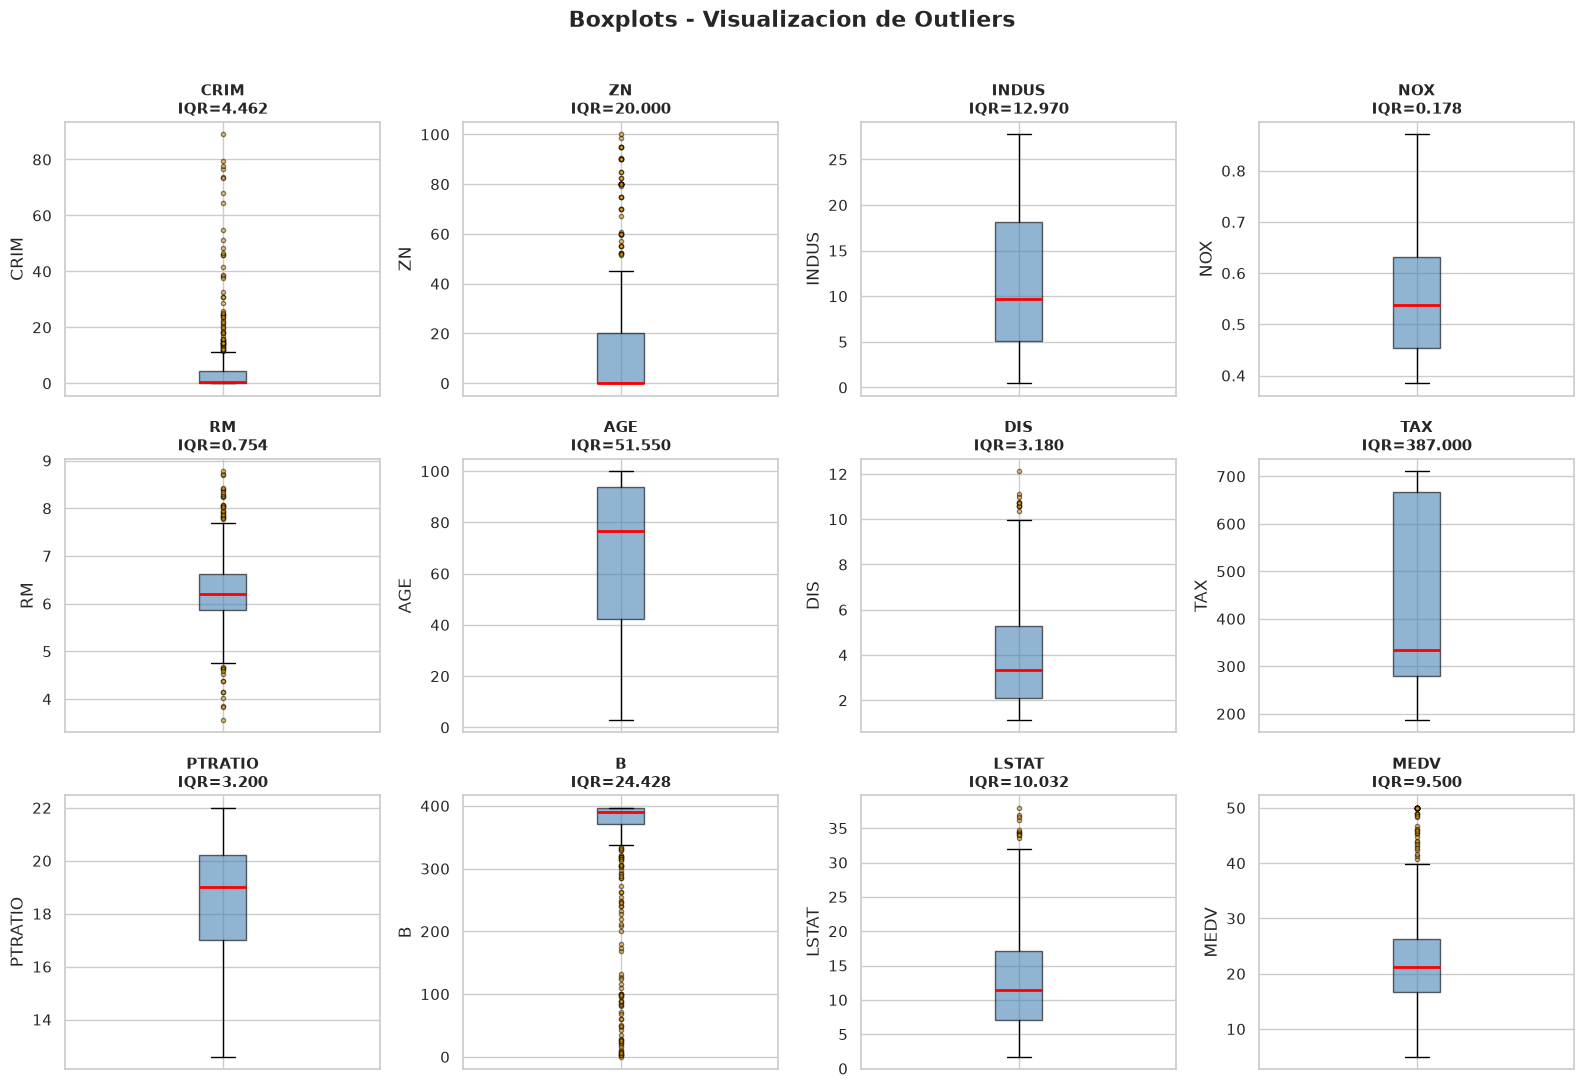

In [44]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    datos = df_casas_limpio[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(columnas_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualizacion de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [45]:
ALPHA = 0.05
SAMPLE_SIZE = 5000  # Para Shapiro-Wilk

resultados_normalidad = []

for col in columnas_numericas:
    datos = df_casas_limpio[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)

    # Shapiro-Wilk (muestra aleatoria si n > 5000)
    if len(datos) > SAMPLE_SIZE:
        muestra = datos.sample(n=SAMPLE_SIZE, random_state=42)
    else:
        muestra = datos
    stat_shap, p_shap = stats.shapiro(muestra)

    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-W': stat_shap,
        'Shapiro-p': p_shap,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Si' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-W,Shapiro-p,DAgostino-K2,DAgostino-p,Normal (alpha=0.05)
0,CRIM,0.4593,0.0000,474.8110,0.0000,No
1,ZN,0.5815,0.0000,212.2087,0.0000,No
2,INDUS,0.9068,0.0000,356.7097,0.0000,No
3,NOX,0.9366,0.0000,37.7544,0.0000,No
4,RM,0.9646,0.0000,26.5557,0.0000,No
5,AGE,0.8942,0.0000,154.8825,0.0000,No
6,DIS,0.9001,0.0000,78.4015,0.0000,No
7,TAX,0.8245,0.0000,295.7152,0.0000,No
8,PTRATIO,0.9073,0.0000,46.5721,0.0000,No
9,B,0.5181,0.0000,279.5886,0.0000,No


como notamos que las variables no son normales, no podemos usar el z-score para la eliminacion de outliers. Por lo tanto usaremos el IQR para esto

In [46]:
IQR_FACTOR = 1.5

reporte_outliers = []

for col in columnas_numericas:
    datos = df_casas_limpio[col].dropna()
    n = len(datos)

    # Metodo IQR
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf_iqr = q1 - IQR_FACTOR * iqr
    lim_sup_iqr = q3 + IQR_FACTOR * iqr
    outliers_iqr = ((datos < lim_inf_iqr) | (datos > lim_sup_iqr)).sum()

    reporte_outliers.append({
        'Variable': col,
        'N': n,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lim_Inf_IQR': lim_inf_iqr,
        'Lim_Sup_IQR': lim_sup_iqr,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100
    })

df_outliers = pd.DataFrame(reporte_outliers)

print('Reporte de Outliers: Metodo IQR')
print('=' * 90)
df_outliers[['Variable', 'N', 'IQR', 'Lim_Inf_IQR', 'Lim_Sup_IQR',
             'Outliers_IQR', 'Pct_IQR(%)']]

Reporte de Outliers: Metodo IQR


,Variable,N,IQR,Lim_Inf_IQR,Lim_Sup_IQR,Outliers_IQR,Pct_IQR(%)
0,CRIM,524,4.4619,-6.6092,11.2382,64,12.2137
1,ZN,523,20.0000,-30.0000,50.0000,54,10.3250
2,INDUS,531,12.9700,-14.3250,37.5550,0,0.0000
3,NOX,526,0.1780,0.1860,0.8980,0,0.0000
4,RM,527,0.7540,4.7455,7.7615,41,7.7799
5,AGE,523,51.5500,-34.9750,171.2250,0,0.0000
6,DIS,529,3.1804,-2.6637,10.0579,10,1.8904
7,TAX,525,387.0000,-301.5000,1246.5000,0,0.0000
8,PTRATIO,525,3.2000,12.2000,25.0000,0,0.0000
9,B,526,24.4275,334.9737,432.6838,87,16.5399


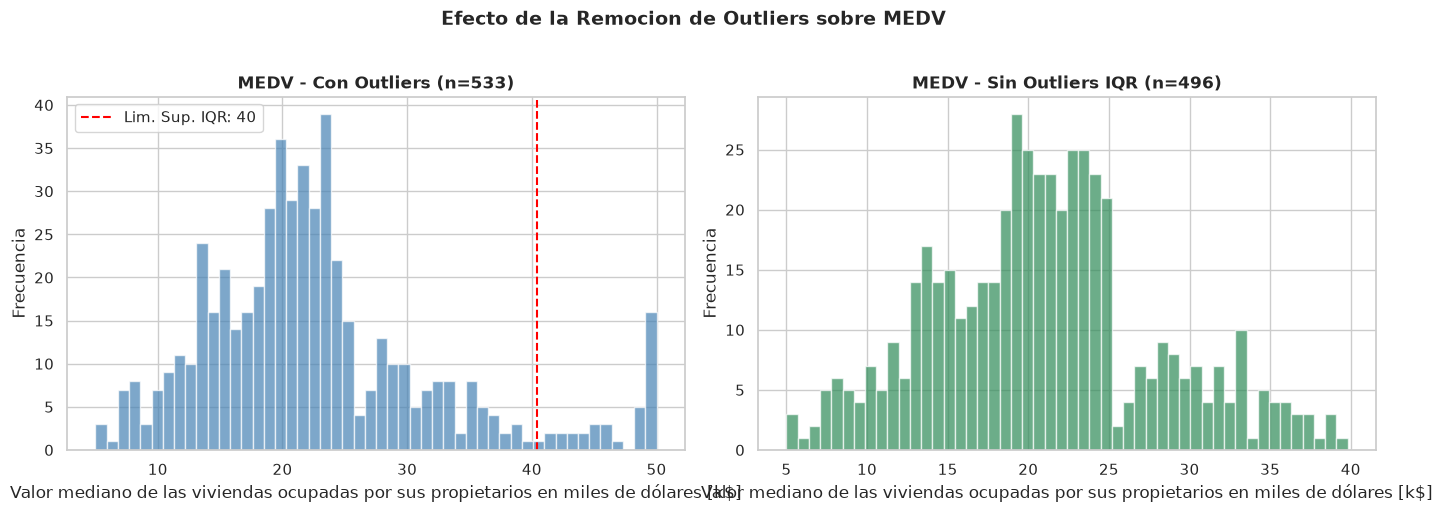

Registros eliminados: 37 (6.94%)


In [47]:
col_ejemplo = 'MEDV'
datos = df_casas_limpio[col_ejemplo].dropna()

# Limites IQR
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con outliers
axes[0].hist(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(lim_sup, color='red', linestyle='--',
                label=f'Lim. Sup. IQR: {lim_sup:.0f}')
axes[0].set_title(f'{col_ejemplo} - Con Outliers (n={len(datos)})',
                  fontweight='bold')
axes[0].set_xlabel('Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares [k$]')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Sin outliers
axes[1].hist(datos_sin_outliers, bins=50, color='seagreen',
             edgecolor='white', alpha=0.7)
axes[1].set_title(f'{col_ejemplo} - Sin Outliers IQR (n={len(datos_sin_outliers)})',
                  fontweight='bold')
axes[1].set_xlabel('Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares [k$]')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Efecto de la Remocion de Outliers sobre {col_ejemplo}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Registros eliminados: {len(datos) - len(datos_sin_outliers)} '
      f'({(len(datos) - len(datos_sin_outliers)) / len(datos) * 100:.2f}%)')

In [48]:
matriz=df_casas_limpio.corr(method='pearson')

<Axes: >

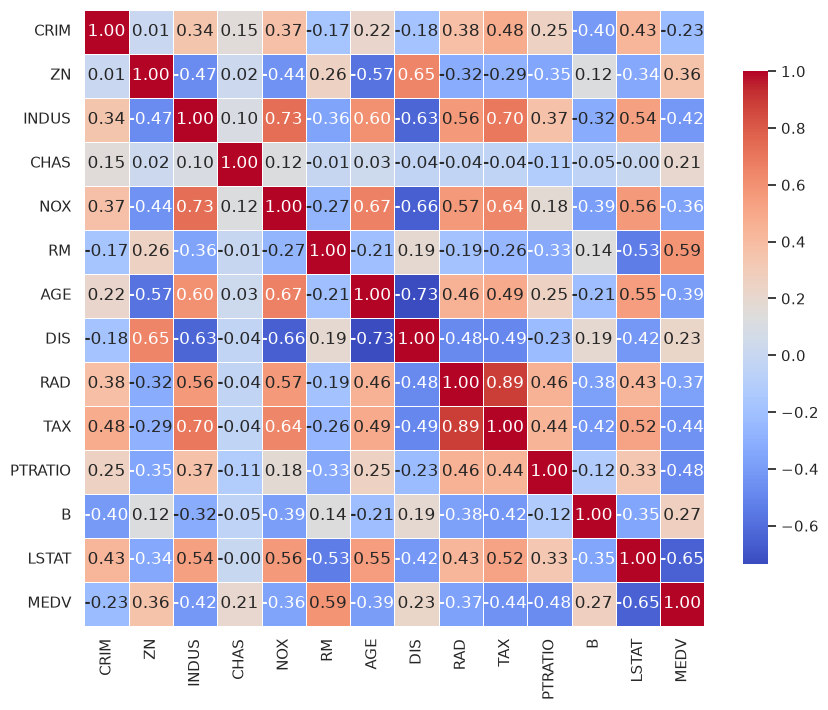

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    data=matriz, 
    annot=True,            # Muestra el valor numérico dentro de cada celda
    fmt=".2f",             # Formato del número (ej. ".2f" para 2 decimales, "d" para enteros)
    cmap="coolwarm",       # Paleta de colores atractiva
    linewidths=0.5,        # Agrega líneas de separación entre las celdas
    linecolor='white',     # Color de las líneas de separación
    cbar_kws={"shrink": .8} # Ajusta el tamaño de la barra de colores lateral
)

## Conclusiones de la Matriz de Correlación

1. Multicolinealidad (El caso de RAD y TAX)
 En el gráfico se observa una correlación altísima de 0.89 entre RAD (accesibilidad a autopistas) y TAX (tasa de impuestos). Aunque parezcan conceptos que no tienen nada que ver, en el contexto geográfico de Boston están ligados: las zonas más urbanizadas y céntricas suelen tener tanto los impuestos más altos como el mayor acceso a las autopistas principales, mientras que los suburbios alejados tienen menos de ambas.

In [50]:
"""
# Definimos las variables redundantes que vamos a volar por multicolinealidad
columnas_a_eliminar = ['RAD']

# Dropeamos las columnas para crear nuestro dataset final
df_final = df_casas_estandarizado.drop(columns=columnas_a_eliminar)

# Vemos cómo quedaron las features finales
print("Columnas finales para entrenar el modelo:")
print(df_final.columns.tolist())
"""

'\n# Definimos las variables redundantes que vamos a volar por multicolinealidad\ncolumnas_a_eliminar = [\'RAD\']\n\n# Dropeamos las columnas para crear nuestro dataset final\ndf_final = df_casas_estandarizado.drop(columns=columnas_a_eliminar)\n\n# Vemos cómo quedaron las features finales\nprint("Columnas finales para entrenar el modelo:")\nprint(df_final.columns.tolist())\n'

# INVESTIGAR.............

### Análisis de Distribuciones e Imputación de Valores Faltantes (NaN)

A partir de la visualización de los histogramas de cada variable, podemos sacar varias conclusiones clave que justifican nuestra estrategia para tratar los datos nulos:

* **Asimetría marcada (Variables sesgadas):** Observamos que variables como `CRIM` (tasa de criminalidad), `ZN`, `DIS`, `B` y `LSTAT` tienen una distribución fuertemente asimétrica, con "colas largas" y presencia de valores extremos (*outliers*). En estos casos, imputar los valores faltantes utilizando el **promedio (media)** es un error, ya que los *outliers* distorsionan el valor medio. Por este motivo, optamos por utilizar la **mediana**, que es una medida de tendencia central mucho más robusta frente a datos extremos.
* **Distribuciones bimodales o irregulares:** Columnas como `RAD` y `TAX` presentan acumulaciones en los extremos en lugar de un pico central. Usar el promedio acá podría darnos un valor de relleno que caiga en un "hueco" donde realmente no hay datos representativos en la realidad. Nuevamente, la mediana resulta ser una opción más segura.
* **Variables Binarias/Categóricas (`CHAS`):** La variable `CHAS` es binaria e indica si la propiedad limita con el río (1) o no (0). Matemáticamente no tiene sentido aplicarle una mediana o un promedio a una categoría. Como la inmensa mayoría de las propiedades en este dataset tienen el valor `0` (no limitan con el río), la mejor decisión es rellenar los nulos con la **moda** (el valor más frecuente, es decir, el `0`).
* **Variable Objetivo (`MEDV`):** Dado que `MEDV` es el valor de la vivienda y representa exactamente lo que nuestro modelo de regresión va a intentar predecir, **nunca se deben imputar sus nulos**. Rellenar la variable objetivo equivale a enseñarle al algoritmo con datos inventados, lo cual sesgaría el modelo. Por ello, la decisión fue eliminar las filas donde el precio era nulo.

**Estrategia final aplicada:**
1. Eliminación de filas con nulos en la variable objetivo (`MEDV`) y de aquellas filas que tenían más de un 50% de datos faltantes.
2. Imputación con `0` (la moda) para los nulos de la variable categórica `CHAS`.
3. Imputación con la **mediana** para los nulos del resto de las variables numéricas continuas.

In [51]:
# Recorremos cada columna dentro de tu lista de numéricas
for col in columnas_numericas:
    # Calculamos la mediana de la columna actual
    mediana = df_casas_limpio[col].median()
    # Rellenamos los vacíos (NaN) con esa mediana
    df_casas_limpio[col] = df_casas_limpio[col].fillna(mediana)

# Comprobamos cómo quedaron los nulos en esas columnas
print("Nulos restantes en columnas numéricas:")
print(df_casas_limpio[columnas_numericas].isnull().sum())

Nulos restantes en columnas numéricas:
CRIM       0
ZN         0
INDUS      0
NOX        0
RM         0
AGE        0
DIS        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [52]:
# Rellenamos los valores faltantes de la columna CHAS con 0
df_casas_limpio['CHAS'] = df_casas_limpio['CHAS'].fillna(df_casas_limpio['CHAS'].mode()[0])

print("Total de nulos en el dataset completo:", df_casas_limpio.isnull().sum().sum())


Total de nulos en el dataset completo: 0


In [53]:
scaler = StandardScaler()

df_casas_estandarizado = pd.DataFrame(
    scaler.fit_transform(df_casas_limpio[columnas_numericas]),
    columns=columnas_numericas,
    index=df_casas_limpio.index
)

print('Verificacion post-estandarizacion:')
print('=' * 50)
verificacion = pd.DataFrame({
    'Media': df_casas_estandarizado.mean(),
    'Std': df_casas_estandarizado.std(),
    'Min': df_casas_estandarizado.min(),
    'Max': df_casas_estandarizado.max()
})
print(verificacion)
print()
print('Media ~ 0 y Std ~ 1 para todas las variables: estandarizacion correcta.')

Verificacion post-estandarizacion:
          Media    Std     Min    Max
CRIM     0.0000 1.0009 -0.4138 7.0972
ZN      -0.0000 1.0009 -0.5069 3.6499
INDUS   -0.0000 1.0009 -1.5581 2.3920
NOX      0.0000 1.0009 -1.4718 2.6576
RM       0.0000 1.0009 -3.6247 3.3416
AGE      0.0000 1.0009 -2.3059 1.1370
DIS      0.0000 1.0009 -1.2564 3.7605
TAX     -0.0000 1.0009 -1.3290 1.8157
PTRATIO  0.0000 1.0009 -2.6754 1.6372
B       -0.0000 1.0009 -3.6494 0.4730
LSTAT    0.0000 1.0009 -1.5042 3.3555
MEDV     0.0000 1.0009 -1.8705 2.8762

Media ~ 0 y Std ~ 1 para todas las variables: estandarizacion correcta.


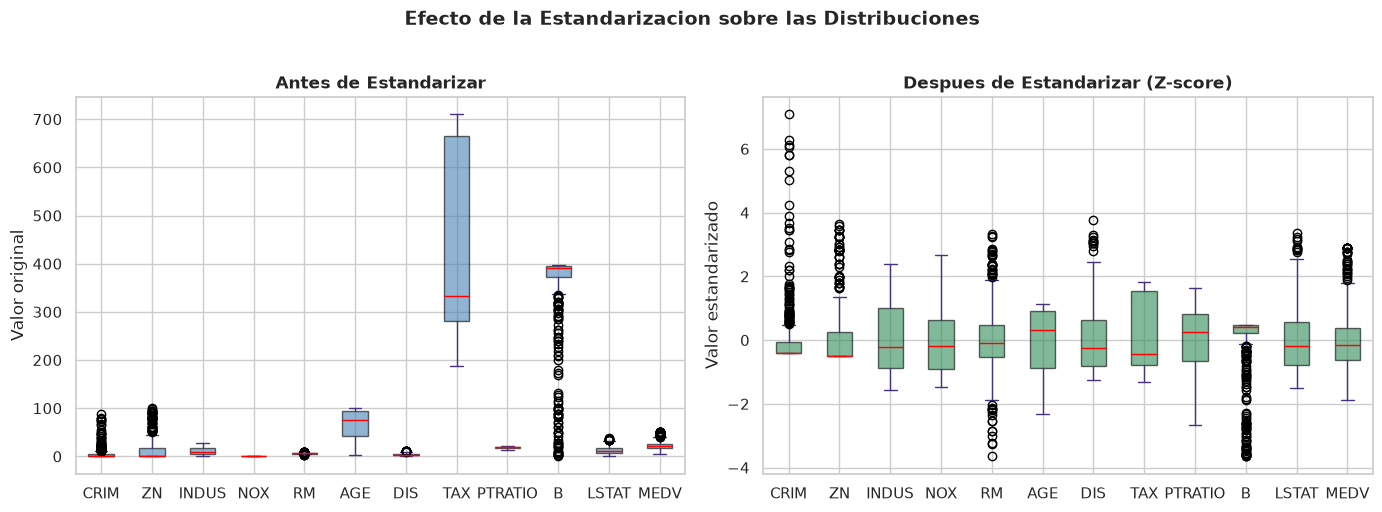

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
df_casas_limpio[columnas_numericas].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red'))
axes[0].set_title('Antes de Estandarizar', fontweight='bold')
axes[0].set_ylabel('Valor original')

# Despues
df_casas_estandarizado[columnas_numericas].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6),
    medianprops=dict(color='red'))
axes[1].set_title('Despues de Estandarizar (Z-score)', fontweight='bold')
axes[1].set_ylabel('Valor estandarizado')

plt.suptitle('Efecto de la Estandarizacion sobre las Distribuciones',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()